# Predicting Water Pump Functionality in Tanzania (HydroLogic Project)
By: Farzaneh Gerami, Subaye Opoku-Acquah and Mariam Farda-Sarbas
March - June 2025

# Overview
A machine learning project to predict the functionality status of water pumps across Tanzania based on a variety of features including location, water quality, management structure, and technical specifications. It addresses a critical infrastructure challenge: identifying which water pumps are functional, need repairs, and are non-functional.

# Introduction
Access to clean and reliable water is fundamental to public health and socio-economic development. In Tanzania, ensuring sustainable water supply and sanitation services is a priority aligned with global initiatives like the Sustainable Development Goals (SDGs), particularly SDG 6, which emphasizes the availability and sustainable management of water and sanitation for all. The Ministry of Water has developed comprehensive guidelines, such as the Design, Construction, Supervision, Operation, and Maintenance (DCOM) manual, to support the planning and implementation of water supply projects across the country.

# Problem Statement
Despite significant efforts, many communities in Tanzania still face challenges with non-functional or partially functional water pumps, leading to inconsistent access to clean water. Factors contributing to this issue include inadequate maintenance, environmental conditions, and technical failures. Addressing these challenges requires a systematic approach to predict and monitor water pump functionality, enabling timely interventions and resource allocation.

# Project Goal
The primary objective of this project is to develop machine learning models capable of predicting the functionality status of water pumps across Tanzania. By analyzing various factors such as location, water quality, management structures, and technical specifications, the project aims to identify which pumps are functional, which require repairs, and which are non-functional. This predictive capability will enhance maintenance operations, ensure better resource distribution, and ultimately improve access to clean water for communities.

# Sources: 
1. Water.org (https://water.org/our-impact/where-we-work/tanzania/)
2. WasserStiftung (https://water.org/our-impact/where-we-work/tanzania/)
3. Chowdavarapu,I.K., Manikandan, V.D. (2016). Data Mining the Water Pumps: Determining the functionality of Water 
Pumps in Tanzania using SAS® Enterprise Miner 
4. IBM (https://www.ibm.com/think/topics/predictive-maintenance)

# Imports

In [1]:
# Imports
import pandas as pd
import numpy as np

# for Box-Cox Transformation
from scipy import stats
from scipy.stats import f_oneway

import math
import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


## Read in all our Data

Question: here i load the data from the local repository
// df_values = pd.read_csv('../data/raw/Training_Set_Values.csv')
// df_labels = pd.read_csv('../data/raw/Training_Set_Labels.csv')

In [3]:
# Load features and labels
train_labels = pd.read_csv("../data/raw/Training_Set_Labels.csv")
train_values = pd.read_csv("../data/raw/Training_Set_Values.csv")
test_values = pd.read_csv("../data/raw/Test_Set_Values.csv")
print('Data is loaded!')

Data is loaded!


## Preview the dataset

In [4]:
# Preview the dataset
train_labels.head(10)

,id,status_group
0,69572,functional
1,8776,functional
2,34310,functional
3,67743,non functional
4,19728,functional
5,9944,functional
6,19816,non functional
7,54551,non functional
8,53934,non functional
9,46144,functional


In [5]:
# Preview the dataset
train_values.head(10)

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
5,9944,20.0,2011-03-13,Mkinga Distric Coun,0,DWE,39.172796,-4.765587,Tajiri,0,...,per bucket,salty,salty,enough,enough,other,other,unknown,communal standpipe multiple,communal standpipe
6,19816,0.0,2012-10-01,Dwsp,0,DWSP,33.362410,-3.766365,Kwa Ngomho,0,...,never pay,soft,good,enough,enough,machine dbh,borehole,groundwater,hand pump,hand pump
7,54551,0.0,2012-10-09,Rwssp,0,DWE,32.620617,-4.226198,Tushirikiane,0,...,unknown,milky,milky,enough,enough,shallow well,shallow well,groundwater,hand pump,hand pump
8,53934,0.0,2012-11-03,Wateraid,0,Water Aid,32.711100,-5.146712,Kwa Ramadhan Musa,0,...,never pay,salty,salty,seasonal,seasonal,machine dbh,borehole,groundwater,hand pump,hand pump
9,46144,0.0,2011-08-03,Isingiro Ho,0,Artisan,30.626991,-1.257051,Kwapeto,0,...,never pay,soft,good,enough,enough,shallow well,shallow well,groundwater,hand pump,hand pump


# Merge Train Data

In [7]:
# Merge them
#df_train = train_values.merge(train_labels, on="id", how="left")
df_train = pd.merge(train_values, train_labels, on='id')
# df = pd.concat([df_values, df_labels], axis=1)

df_train.to_csv('../data/processed/merged_trained_data.csv', index=False) 

# Preview the dataset
df_train.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


# Basic Exploration

In [37]:
# Shape of the dataset
print("Training Shape:", df_train.shape)
print("Test Shape:", test_values.shape)

Training Shape: (59400, 41)
Test Shape: (14850, 40)


### Overview of data types & missing values

In [38]:
# Overview of data types
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

# Summary Statistics

In [28]:
# Summary statistics for numerical features
df_train.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


Based on Chatgpt the min and max for Tanzania is: Latitude: ~-11.75° to -1.00° , Longitude: ~29.35°E to 40.45°E. 

In [29]:
# Look at the distribution of the target variable
df_train['status_group'].value_counts()

status_group
functional                 32259
non functional             22824
functional needs repair     4317
Name: count, dtype: int64

## Dataset Profile Summary

In [9]:
# Basic summary statics
def feature_summary(df):
    summary = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Values': df.isnull().sum(),
        'Zero Values': (df == 0).sum(),
        'Unique Values': df.nunique()
    })
    # Add Percent of Missing Values
    summary['% Missing'] = (summary['Missing Values'] / len(df)) * 100
    
    # Classify Feature Type
    def classify_feature(col):
        if df[col].dtype == 'object':
            return 'Categorical'
        elif df[col].dtype in ['int64', 'float64']:
            if df[col].nunique() < 15:
                return 'Ordinal/Categorical'
            return 'Numerical'
        elif df[col].dtype == 'bool':
            return 'Boolean'
        elif 'date' in col:
            return 'Date'
        else:
            return 'Other'
    # Applies the classifier to each column.
    summary['Feature Type'] = summary.index.to_series().apply(classify_feature)
    return summary.sort_values(by='Missing Values', ascending=False)

# Run the summary
feature_summary(df_train)

,Data Type,Missing Values,Zero Values,Unique Values,% Missing,Feature Type
scheme_name,object,28810,0,2695,48.501684,Categorical
scheme_management,object,3878,0,11,6.528620,Categorical
installer,object,3655,0,2145,6.153199,Categorical
funder,object,3637,0,1896,6.122896,Categorical
public_meeting,object,3334,5055,2,5.612795,Categorical
permit,object,3056,17492,2,5.144781,Categorical
subvillage,object,371,0,19287,0.624579,Categorical
wpt_name,object,2,0,37399,0.003367,Categorical
water_quality,object,0,0,8,0.000000,Categorical
extraction_type_class,object,0,0,7,0.000000,Categorical


## Details of Features and Target
exploring the most common values in each categorical column

### Location & Demographics:

In [12]:
# Select categorical columns
demo_categorical = df_train[['gps_height','longitude','latitude','region','region_code','district_code','lga','ward','subvillage','population','wpt_name']]

# Count unique values
for col in demo_categorical:
    print(f"{col}:\n", df_train[col].value_counts(normalize=True).sort_values(ascending=False))

gps_height:
 gps_height
 0       0.344074
-15      0.001010
-16      0.000926
-13      0.000926
 1290    0.000875
           ...   
 2523    0.000017
 2401    0.000017
 2491    0.000017
 2302    0.000017
 2366    0.000017
Name: proportion, Length: 2428, dtype: float64
longitude:
 longitude
0.000000     0.030505
33.010510    0.000034
32.955597    0.000034
32.967009    0.000034
37.339811    0.000034
               ...   
33.993468    0.000017
37.728158    0.000017
31.547474    0.000017
31.157624    0.000017
38.104048    0.000017
Name: proportion, Length: 57516, dtype: float64
latitude:
 latitude
-2.000000e-08    0.030505
-6.963557e+00    0.000034
-2.501627e+00    0.000034
-6.981830e+00    0.000034
-2.519950e+00    0.000034
                   ...   
-7.088183e+00    0.000017
-9.441295e+00    0.000017
-7.014732e+00    0.000017
-1.798378e+00    0.000017
-6.747464e+00    0.000017
Name: proportion, Length: 57517, dtype: float64
region:
 region
Iringa           0.089125
Shinyanga        0.0838

### Water Source Info

In [13]:
water_categorical = df_train[['source','source_type','source_class','water_quality','quality_group','quantity','quantity_group','amount_tsh','num_private']]

# Count unique values
for col in water_categorical:
    print(f"{col}:\n", df_train[col].value_counts(normalize=True).sort_values(ascending=False))

source:
 source
spring                  0.286549
shallow well            0.283232
machine dbh             0.186448
river                   0.161818
rainwater harvesting    0.038636
hand dtw                0.014714
lake                    0.012879
dam                     0.011044
other                   0.003569
unknown                 0.001111
Name: proportion, dtype: float64
source_type:
 source_type
spring                  0.286549
shallow well            0.283232
borehole                0.201162
river/lake              0.174697
rainwater harvesting    0.038636
dam                     0.011044
other                   0.004680
Name: proportion, dtype: float64
source_class:
 source_class
groundwater    0.770943
surface        0.224377
unknown        0.004680
Name: proportion, dtype: float64
water_quality:
 water_quality
soft                  0.855522
salty                 0.081751
unknown               0.031582
milky                 0.013535
coloured              0.008249
salty abandon

### Pump/Infrastructure Info

In [14]:
pump_categorical = df_train[['funder','installer','construction_year','permit','scheme_name','management','management_group','scheme_management']]

# Count unique values
for col in pump_categorical:
    print(f"{col}:\n", df_train[col].value_counts(normalize=True).sort_values(ascending=False))

funder:
 funder
Government Of Tanzania    0.162904
Danida                    0.055843
Hesawa                    0.039489
Rwssp                     0.024640
World Bank                0.024192
                            ...   
Caltas Tanzania           0.000018
Kikundi Cha Akina Mama    0.000018
World Vision/rc Church    0.000018
Hesawwa                   0.000018
Samlo                     0.000018
Name: proportion, Length: 1896, dtype: float64
installer:
 installer
DWE           0.312171
Government    0.032738
RWE           0.021634
Commu         0.019015
DANIDA        0.018836
                ...   
Mr Luo        0.000018
VWT           0.000018
Msudi         0.000018
O &           0.000018
SELEPTA       0.000018
Name: proportion, Length: 2145, dtype: float64
construction_year:
 construction_year
0       0.348636
2010    0.044529
2008    0.043990
2009    0.042643
2000    0.035202
2007    0.026717
2006    0.024764
2003    0.021650
2011    0.021145
2004    0.018906
2012    0.018249
2002 

### Technical Characteristics

In [15]:
tech_categorical = df_train[['extraction_type','extraction_type_group','extraction_type_class','waterpoint_type','waterpoint_type_group','date_recorded']]

# Count unique values
for col in tech_categorical:
    print(f"{col}:\n", df_train[col].value_counts(normalize=True).sort_values(ascending=False))

extraction_type:
 extraction_type
gravity                      0.450842
nira/tanira                  0.137273
other                        0.108249
submersible                  0.080202
swn 80                       0.061785
mono                         0.048232
india mark ii                0.040404
afridev                      0.029798
ksb                          0.023822
other - rope pump            0.007593
other - swn 81               0.003855
windmill                     0.001970
india mark iii               0.001650
cemo                         0.001515
other - play pump            0.001431
walimi                       0.000808
climax                       0.000539
other - mkulima/shinyanga    0.000034
Name: proportion, dtype: float64
extraction_type_group:
 extraction_type_group
gravity            0.450842
nira/tanira        0.137273
other              0.108249
submersible        0.104024
swn 80             0.061785
mono               0.048232
india mark ii      0.040404
afridev

### Target Variable

In [16]:
value_counts = df_train['status_group'].value_counts()
total = len(df_train)

for value, count in value_counts.items():
    percent = (count / total) * 100
    print(f"{value}: {count} ({percent:.2f}%)")

functional: 32259 (54.31%)
non functional: 22824 (38.42%)
functional needs repair: 4317 (7.27%)


### Missing Values

In [17]:
#### The percentage of missing values in our train data

# total number of cells in dataframe
total_cells = np.prod(df_train.shape) # np.prod is calculating the product of dimention of the Dataframe

# count missing cells
total_missing = df_train.isnull().sum().sum()

# percent of data that is missing
percent_missing = (total_missing/total_cells) * 100

print(f"Total missing values: {total_missing}")
print(f"Percentage of missing data: {percent_missing:.2f}%")

Total missing values: 46743
Percentage of missing data: 1.92%


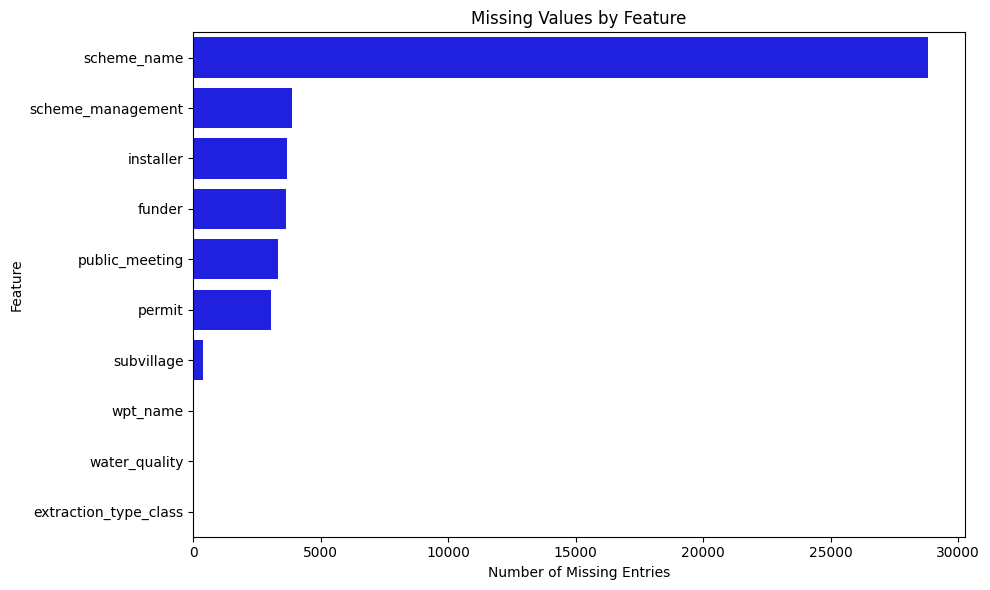

In [19]:
missing_values_count = df_train.isnull().sum().sort_values(ascending=False).head(10)
# Visualizing Missingness

plt.figure(figsize=(10, 6))
sns.barplot(x = missing_values_count.values, y=missing_values_count.index, color='blue')
plt.title('Missing Values by Feature')
plt.xlabel('Number of Missing Entries')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### Zero values

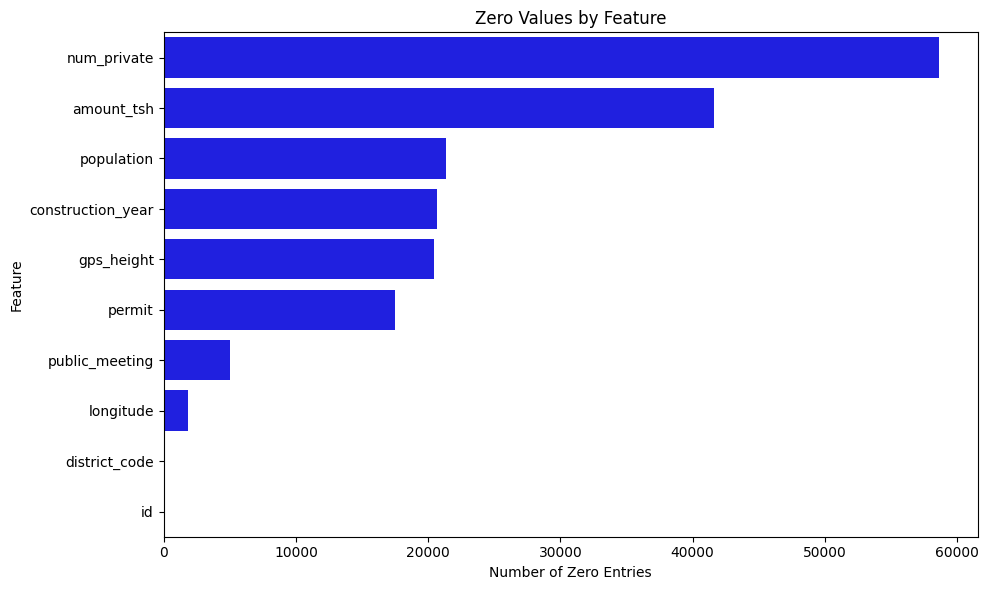

In [20]:
# Count how many times 0 appears in each column
zero_counts = (df_train == 0).sum().sort_values(ascending=False)

# Visualizing and Grouping 0

plt.figure(figsize=(10, 6))
sns.barplot(x = zero_counts.values[:10], y=zero_counts.index[:10], color='blue')
plt.title('Zero Values by Feature')
plt.xlabel('Number of Zero Entries')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Summary of Interpretation:

- status_group: Classes: "functional", "non functional", "functional needs repair". Imbalanced: majority is "functional", with a small percentage needing repair. Model evaluation should use metrics like F1-score, and possibly apply class balancing techniques.

- Date_recorded: This is the date of data collection. We need to change the type to datetime64, extract the year and month to see if there is any meaningful relation between date recorded and group status.

- Recorded_by: This record is person / organization that record the data and all has a GeoData Consultants Ltd. Maybe we can drop that.

- gps_height: Elevaton in meters. range is between -90 - 2770. check if there is any meaningful relation between the target and gps_height.

- Latitude and langitude: latitude 6°23′31.20″ South, longitude 35°00′07.20″ East Source: https://www.mapsofworld.com/lat_long/tanzania-lat-long.html there is a table in this website with the all regions lonitude and latitude. Maybe we can import this table and correct the missing or zero inputs. longitude in table are between min 0 and max 40.35 and latitude in table: min -11.65 to max 0.00000002. we may also can use these region names and other location features to complete the latitude and longitude in geospatial analysis.

- wpt_name: This is name of the waterpoint (WPT = Water Point) most of the values are missed (none). Very high cardinality (possibly unique to each record)

- basin: Clean categorical data. Limited set of known water basins like "Lake Victoria", "Pangani", etc. It is a good candidate for one-hot encoding or label encoding.

- region, lga, ward: Represent hierarchical geographic divisions.region has manageable categories. lga and ward have many unique values. Maybe, we can consider encoding region directly; lga and ward may need grouping or geo-clustering.

- Source and Source_type: They have similar types but source has unknown and source_type has not. Maybe we can group them or use for imputing.

- source_class: Maybe we can guess the unknown by using the source and source_type.because this also has missed value filled by unknown.

- water_quality and quality_group: water_quality and quality_group are similar but the quality group has n unknown or missing values.

- quantity and quantity_group: quantity and quantity_group are both completely similar. we can drop one.

- amount_tsh: It can be the water payment cost (TZ shillings). I have no idea how we can use it.But i think we can see if they could allocate money for repair or not or something like this.

- num_private: Possibly count of private entities. i do not know if this has any meaning while the most fields are 0. Maybe we can drop this column.

- funder: Top funder is "Government Of Tanzania", accounting for a significant portion and Common funders include organizations like Danida and World Bank. Maybe better grouping low-frequency funders into an "Other" category and standardizing names (e.g., "danida" vs. "Danida").

- installer: Similar to funder, has many unique values and inconsistencies. "DWE" is typically the most frequent installer. we can group rare installers, and consider combining near-duplicate values.

- construction_year: the construction happens between 1960 to 2013. we can check if there is any relation between the construction time and the target

- scheme_management and management: I found scheme_management and management quite similar. but management has more missing values.

- extraction_type_class, extraction_type_group, extraction_type: They are talking about the mechanism for drawing water. we have 5 types of other! the extraction_type and extraction_type_group are similar. The extraction_type_class is more general. Maybe we need to see if there any relation between this and the target.

- water_type and water_typegroup: These two features are also quite similar. one has 7 types and the other 6 types. maybe the waterpoint_type is more accurate.

- public_meeting, permit: Boolean-type fields (Yes/No) but may contain missing values. May impute missing values based on related features (e.g., scheme_management) or majority class.

### Questions for Further Investigation
- Can we extract time-based features from `date_recorded`? (e.g., year, month, season)
- How can we handle 0 or missing values in `construction_year`?
- Should rare funders and installers be grouped under "Other" or cleaned up into broader categories?
- Do spatial features (`longitude`, `latitude`, `region`) correlate with pump status?
- Should `wpt_name` be dropped or transformed into something more useful (e.g., location-based clusters)?
- Can we engineer a composite quality score from `water_quality`, `quantity`, and `source`?
- Are there duplicate or redundant columns we could drop?
- Which features are most important in predicting pump functionality?

## Visualisation of Distribution in Numerical Categories

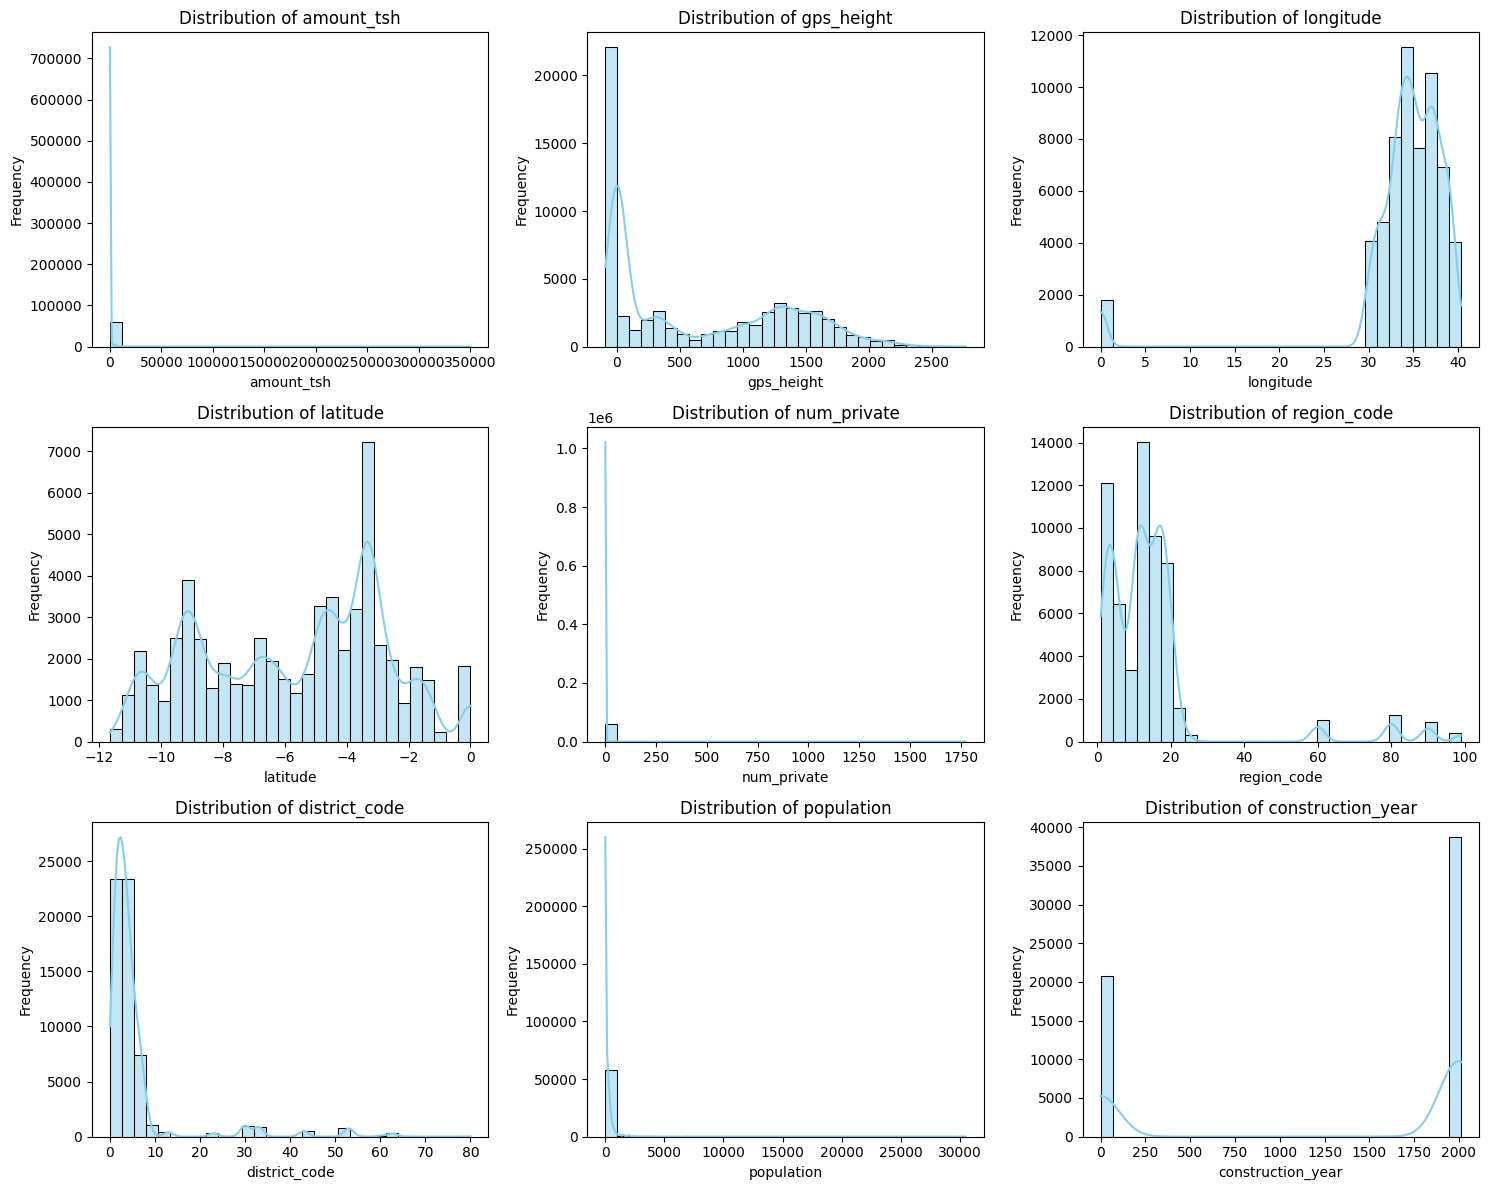

In [73]:
numerical_columns = df_train.select_dtypes(include=['float64', 'int64']).columns
numerical_columns = [col for col in numerical_columns if col != 'id']

# Define the number of rows and columns for subplots
n_cols = 3  # Change this based on how wide you want the frame
n_rows = math.ceil(len(numerical_columns) / n_cols)

# Set figure size (adjust as needed)
plt.figure(figsize=(n_cols * 5, n_rows * 4))

# Loop through each column and plot on the same figure
for i, col in enumerate(numerical_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_train[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()

# Plot interpretations and observations

'id': The distribution appears uniform, with all bars roughly the same height.There’s no skew, peaks, or clusters — just a flat, even spread. This was to be expected given that 'id' is a unique identifier and not tied to any meaningful patterns in the data.

'amount_tsh': The distribution is heavily right-skewed. The majority of values are at or near 0. This is shown by a huge spike at 0 or close to 0. A long tail extends all the way up to 350,000, though these large values are rare. Given that Total static head __"total static head" (TSH)__ in water engineering terms, usually refers to:
- The __vertical distance__ (in meters) from the water source (like a well or borehole) to the __discharge point__ (where water comes out), this skew is not alarming. 

'gps_height': The distribution is heavily right-skewed, with most values concentrated below 2000 meters and a spike at 0.Excluding the spike at 0, the most common values appear to lie between 1000 and 1700 meters. After 2000 meters, the frequency of values drops off significantly. 

'longitude': The majority of values fall between 30 and 40 degrees. This is consistent with countries in East Africa such as Tanzania, Kenya and Uganda. Given that our data is focused on Tanzania, this is to be expected. We find a slight spike in coordinates at longitude 0. This is unrealistic as such coordinates would fall within the Atlantic. (It will be important to look at other data such as region and status_group to determine the value of this column) The data outside the 30–40 range (except 0) is minimal or non-existent. This further suggests the dataset is geographically focused. 

'latitude': The values range from approximately -12 to 0 aligns well with Tanzania, which spans from around -12° to -1° latitude.There's a notable spike at approximately -4, indicating a dense cluster of data points in that latitude.(Further analysis of the data to understand if this correlates to a major population center or a region where data collection was heavily focused) Although there was no clear spike at a latitude of 0 degrees, with a frequency of slightly under 2000 records, further analysis will be needed. 

'population': the data in this column is extremely right-skewed. Most values of the population column are concentrated at the very low end (close to 0). (This column is meant to depict the population around the well. It would be important to understand if this is the same as the population using the well)

'construction_year': The graph has two distinct peaks with a large spike near 0. This likely represents missing or unknown data. The second peak represents the years between 1980-2010. A large portion of data falls in the invalid or missing category. (A possible way to handle these missing years is to consider the date available for construction_year for pumps in the region and find an average)




## Visualisation showing distribution of numerical columns by functionality

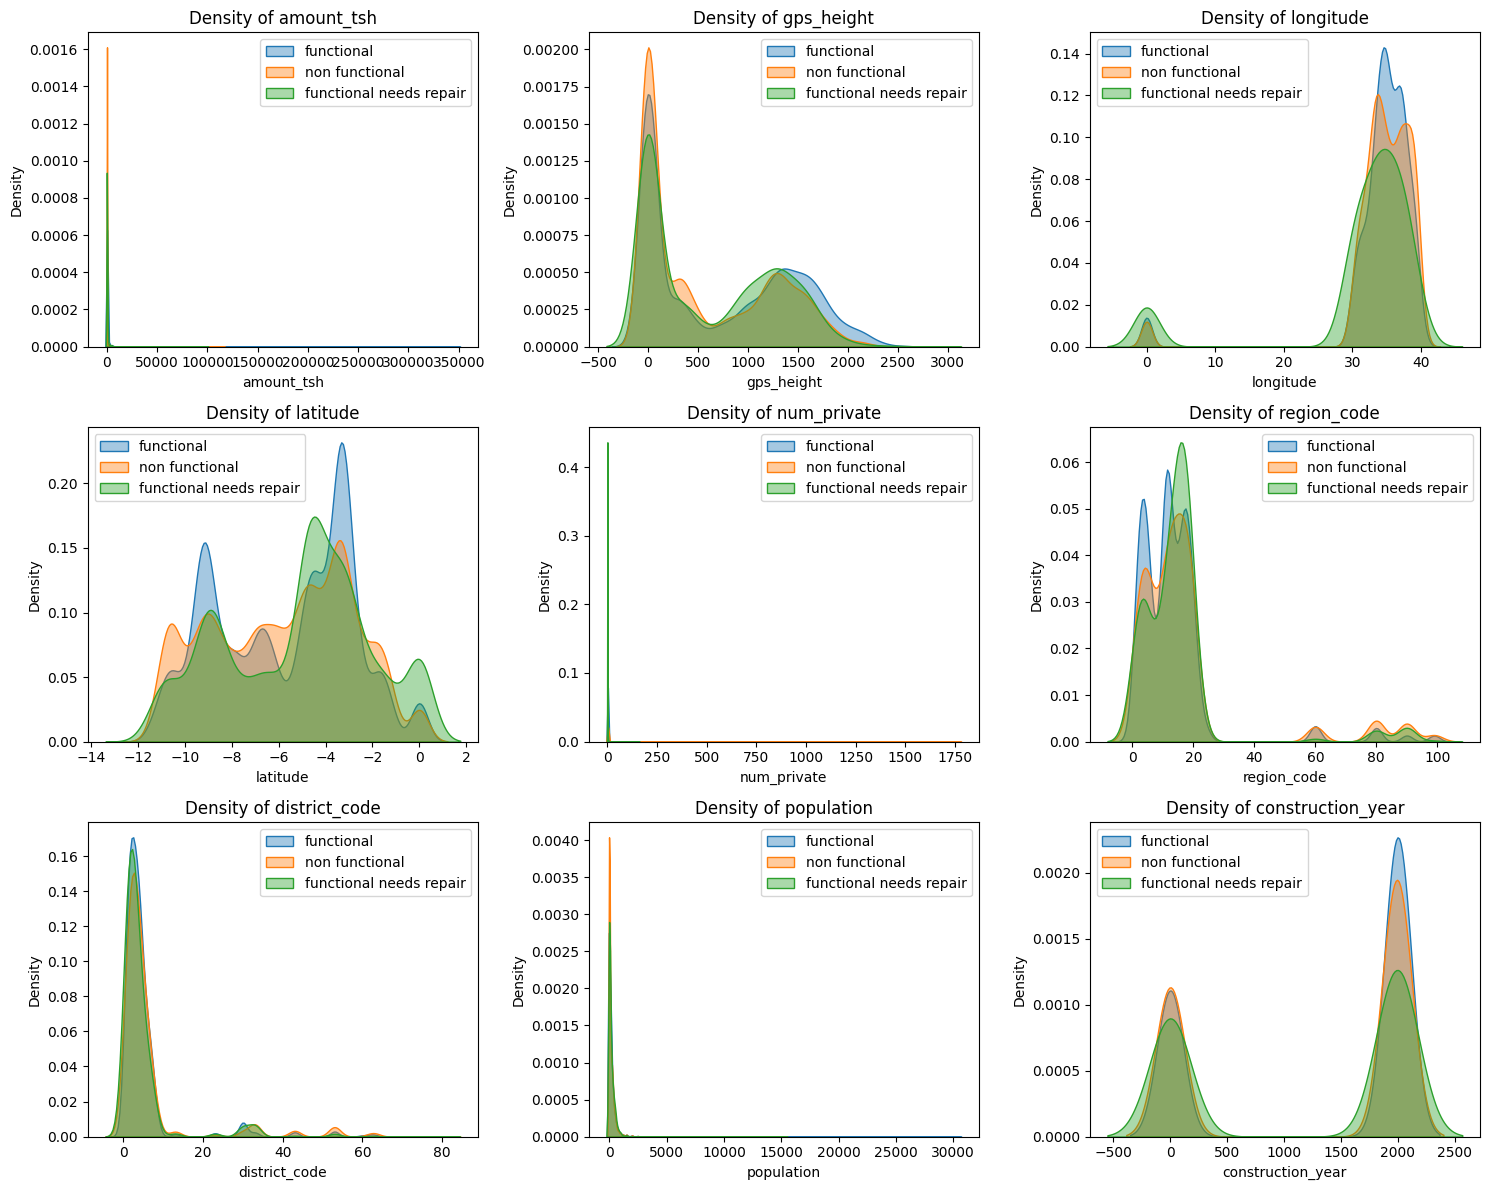

In [74]:
n_cols = 3  # plots per row
n_rows = math.ceil(len(numerical_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()  # Make it easier to index

# Loop through each numerical column
for i, col in enumerate(numerical_columns):
    ax = axes[i]
    for group in df_train['status_group'].unique():
        subset = df_train[df_train['status_group'] == group]
        sns.kdeplot(subset[col], label=group, fill=True, alpha=0.4, ax=ax)
    ax.set_title(f'Density of {col}')
    ax.legend()

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## Finding the relation between the target and some features

In [21]:
# Average gps_height for each status group
df_train.groupby("status_group")["gps_height"].describe()

,count,mean,std,min,25%,50%,75%,max
status_group,,,,,,,,
functional,32259.0,740.131188,724.193683,-90.0,0.0,550.0,1404.0,2628.0
functional needs repair,4317.0,627.607135,648.397850,-51.0,0.0,385.0,1243.0,2770.0
non functional,22824.0,574.464774,642.752316,-59.0,0.0,293.0,1211.0,2627.0


Interpretation: the distribution shows that Functional pumps tend to be located at higher elevations, with both the mean and median GPS height notably higher than those in the "non functional" group.Pumps that need repair lie in between; higher than "non functional" but lower than "functional".

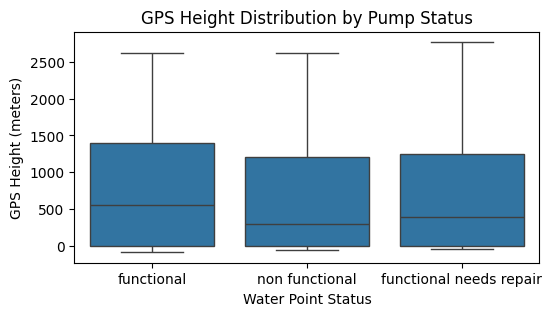

In [25]:
plt.figure(figsize=(6, 3))
sns.boxplot(data=df_train, x="status_group", y="gps_height")
plt.title("GPS Height Distribution by Pump Status")
plt.xlabel("Water Point Status")
plt.ylabel("GPS Height (meters)")
plt.show()

Interpretation: The distribution shifts upward for functional pumps.There's a wider range in GPS height among functional pumps, possibly indicating that these are maintained even in less accessible (higher) areas. Non-functional pumps cluster at lower altitudes, suggesting a possible environmental or logistical factor affecting functionality.

In [26]:
# Extract values for each group
groups = [group["gps_height"].dropna() for name, group in df_train.groupby("status_group")]
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_value:.4f}")

ANOVA F-statistic: 395.01, p-value: 0.0000


A small p-value (e.g. < 0.05) indicates a significant difference in gps_height among the status_groups.

Conclusion: My conclusion is that there is a strong relationship between water pump functionality (status_group) and elevation (gps_height). the plot and means shows that Higher elevation pumps are more likely to be functional, possibly due to better installation/maintenance or less groundwater contamination.

In [27]:
# Average latitude for each status group
df_train.groupby("status_group")["latitude"].describe()

,count,mean,std,min,25%,50%,75%,max
status_group,,,,,,,,
functional,32259.0,-5.704921,2.897323,-11.564324,-8.640908,-4.904257,-3.322252,-2.000000e-08
functional needs repair,4317.0,-5.162580,3.099036,-11.649440,-7.860679,-4.656811,-3.158054,-2.000000e-08
non functional,22824.0,-5.810394,2.973262,-11.586297,-8.515783,-5.421238,-3.350447,-2.000000e-08


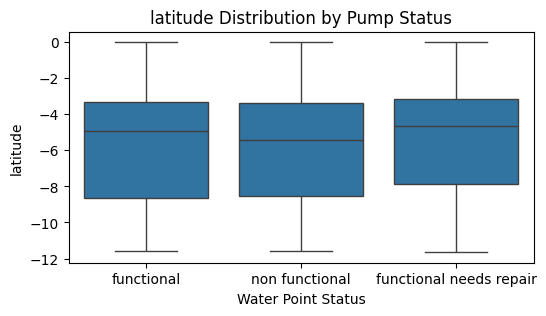

In [30]:
plt.figure(figsize=(6, 3))
sns.boxplot(data=df_train, x="status_group", y="latitude")
plt.title("latitude Distribution by Pump Status")
plt.xlabel("Water Point Status")
plt.ylabel("latitude")
plt.show()

In [31]:
# Extract values for each group
groups = [group["latitude"].dropna() for name, group in df_train.groupby("status_group")]
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_value:.4f}")

ANOVA F-statistic: 88.03, p-value: 0.0000


Conclusion: More functional pumps are located further north (closer to 0° latitude).Non-functional pumps are generally further south (larger negative values). I think we have to look to the governance, installer and funder to know if there is any relation between them. maybe in the northen areas have better access to the resources or better government support and in the southern area face some challenges for the maintenance for example weaker funder or installer. Also we can research about the different weather in different geographic location. Maybe that can impact the water and the technology suitability. or also we can look the region, if it is in the urban or rural areas.

In [32]:
# Average Longitude for each status group
df_train.groupby("status_group")["longitude"].describe()

,count,mean,std,min,25%,50%,75%,max
status_group,,,,,,,,
functional,32259.0,34.242071,6.200054,0.0,33.368557,34.969884,37.057074,40.345193
functional needs repair,4317.0,31.242086,10.169667,0.0,30.799300,33.827215,36.668018,40.283599
non functional,22824.0,34.381006,6.059035,0.0,33.002248,34.958415,37.567890,40.344301


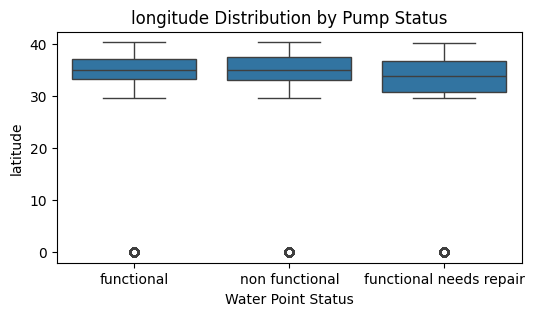

In [33]:
plt.figure(figsize=(6, 3))
sns.boxplot(data=df_train, x="status_group", y="longitude")
plt.title("longitude Distribution by Pump Status")
plt.xlabel("Water Point Status")
plt.ylabel("latitude")
plt.show()

In [34]:
# Extract values for each group
groups = [group["longitude"].dropna() for name, group in df_train.groupby("status_group")]
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_value:.4f}")

ANOVA F-statistic: 443.35, p-value: 0.0000


Conclusion: western Tanzania (lower longitude) seems to have more pupms needing repair. that can have any reason, maybe that is better to know the relation between the funder, installer and the goverment if they support the maintenance or not! Central and Eastern regions (mid to high longitudes) maintain a better balance between functional and non-functional pumps.

In [35]:
# Average amount_tsh for each status group
df_train.groupby("status_group")["amount_tsh"].describe()

,count,mean,std,min,25%,50%,75%,max
status_group,,,,,,,,
functional,32259.0,461.798235,3889.735284,0.0,0.0,0.0,50.0,350000.0
functional needs repair,4317.0,267.071577,1925.026420,0.0,0.0,0.0,50.0,100000.0
non functional,22824.0,123.481230,1110.120571,0.0,0.0,0.0,0.0,117000.0


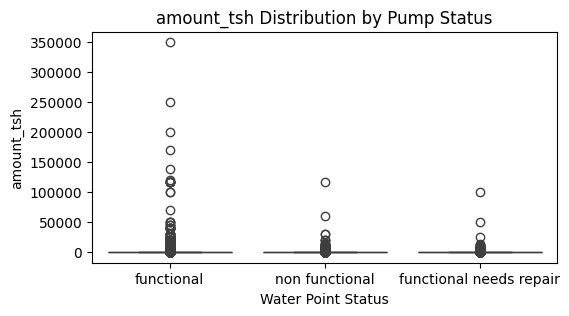

In [36]:
plt.figure(figsize=(6, 3))
sns.boxplot(data=df_train, x="status_group", y="amount_tsh")
plt.title("amount_tsh Distribution by Pump Status")
plt.xlabel("Water Point Status")
plt.ylabel("amount_tsh")
plt.show()

In [37]:
# Extract values for each group
groups = [group["amount_tsh"].dropna() for name, group in df_train.groupby("status_group")]
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_value:.4f}")

ANOVA F-statistic: 86.04, p-value: 0.0000


Conclusion: seems that amount paid (amount_tsh) is significantly related to pump functionality. this has too much 0 that may impact. we have to look again after handling missing data.

In [38]:
# Average population for each status group
df_train.groupby("status_group")["population"].describe()

,count,mean,std,min,25%,50%,75%,max
status_group,,,,,,,,
functional,32259.0,187.553303,513.198991,0.0,0.0,40.0,200.0,30500.0
functional needs repair,4317.0,175.102154,433.033756,0.0,0.0,25.0,245.0,15300.0
non functional,22824.0,170.016430,413.094978,0.0,0.0,1.0,230.0,9865.0


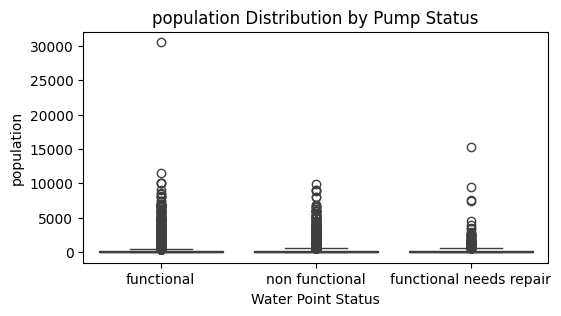

In [39]:
plt.figure(figsize=(6, 3))
sns.boxplot(data=df_train, x="status_group", y="population")
plt.title("population Distribution by Pump Status")
plt.xlabel("Water Point Status")
plt.ylabel("population")
plt.show()

In [40]:
# Extract values for each group
groups = [group["population"].dropna() for name, group in df_train.groupby("status_group")]
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_value:.4f}")

ANOVA F-statistic: 9.49, p-value: 0.0001


Conclusion: seems again that population size has a significant relationship with pump functionality. This also has so much 0 that should be considered before having any conclusion.

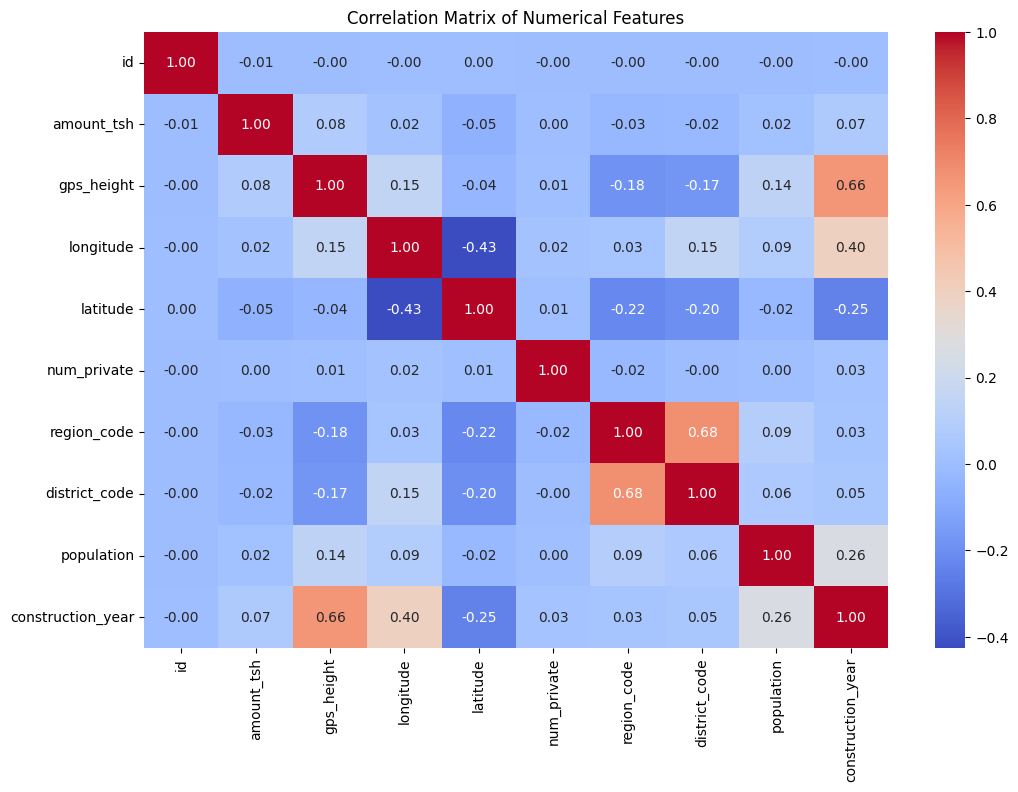

In [41]:
# Correlation Matrix
plt.figure(figsize=(12, 8))
corr_matrix = df_train.select_dtypes(include='number').corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()